Running sweep for 4 rules...
Sweep complete. Generating TP% grid...



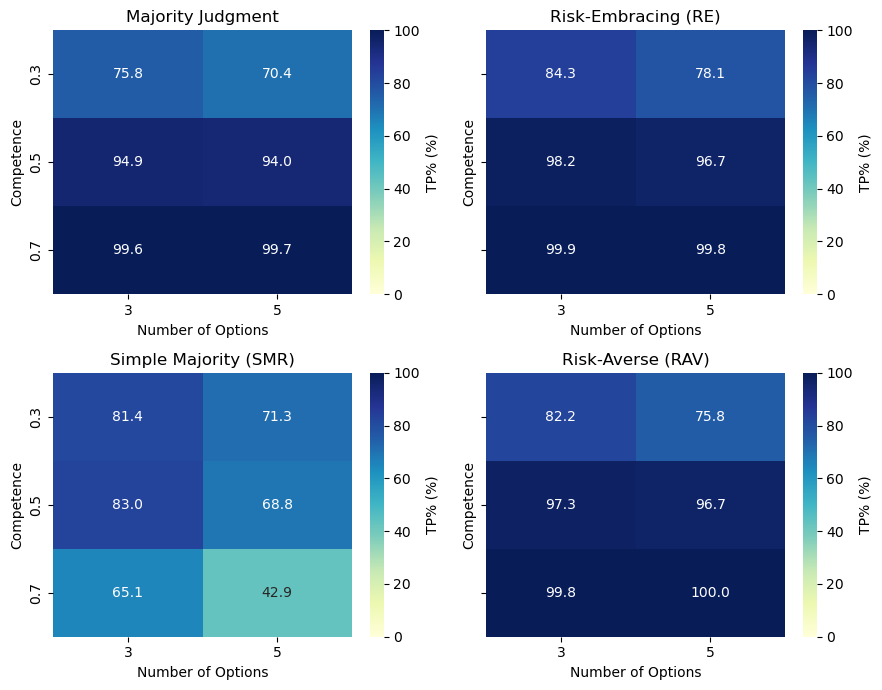

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from enum import IntEnum

# ─────────────────────────────────────────────────────────────────────────────
# 1. GRADES & SIMULATION
# ─────────────────────────────────────────────────────────────────────────────
class Grade(IntEnum):
    P = 0; F = 1; G = 2; VG = 3; E = 4

def majority_grade(grades: np.ndarray) -> int:
    return np.sort(grades)[::-1][(len(grades) - 1) // 2]

def dominates(sorted_a: np.ndarray, sorted_b: np.ndarray) -> bool:
    return np.all(sorted_a >= sorted_b) and np.any(sorted_a > sorted_b)

def compare_options(grades_a: np.ndarray, grades_b: np.ndarray, rule: str) -> str:
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a, med_b = majority_grade(grades_a), majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    if dominates(sorted_a, sorted_b): return 'A'
    if dominates(sorted_b, sorted_a): return 'B'
    
    # Rule-specific tie-breaking
    above_a = sorted_a[sorted_a > med_a]
    above_b = sorted_b[sorted_b > med_b]
    below_a = sorted_a[sorted_a < med_a]
    below_b = sorted_b[sorted_b < med_b]
    
    if rule == 'RE':
        # Higher upper tail
        max_a = np.max(above_a) if len(above_a) > 0 else -1
        max_b = np.max(above_b) if len(above_b) > 0 else -1
        if max_a > max_b: return 'A'
        if max_b > max_a: return 'B'
        if len(above_a) > len(above_b): return 'A'
        if len(above_b) > len(above_a): return 'B'
        rule = 'MJ'  # fallback
        
    elif rule == 'RAV':
        # Higher lower tail (more/better grades below median)
        max_a = np.max(below_a) if len(below_a) > 0 else -1
        max_b = np.max(below_b) if len(below_b) > 0 else -1
        if max_a > max_b: return 'A'
        if max_b > max_a: return 'B'
        if len(below_a) > len(below_b): return 'A'
        if len(below_b) > len(below_a): return 'B'
        rule = 'MJ'  # fallback
        
    # MJ fallback: prefer less extreme / more consensual
    var_a, var_b = np.var(sorted_a), np.var(sorted_b)
    if var_a < var_b: return 'A'
    if var_b < var_a: return 'B'
    return 'TIE'

def select_best(grades_matrix: np.ndarray, rule: str) -> int:
    if rule == 'SMR':
        # Simple Majority Rule: count votes for highest grade per agent
        votes = np.zeros(grades_matrix.shape[1], dtype=int)
        max_grades = np.max(grades_matrix, axis=0)
        for j in range(grades_matrix.shape[1]):
            votes[j] = np.sum(grades_matrix[:, j] == max_grades[j])
        max_votes = np.max(votes)
        candidates = np.where(votes == max_votes)[0]
        return np.random.choice(candidates)
    else:
        best = 0
        for j in range(1, grades_matrix.shape[1]):
            cmp = compare_options(grades_matrix[:, best], grades_matrix[:, j], rule)
            if cmp == 'B': best = j
        return best

def simulate_round(n_agents: int, n_options: int, competence: float, truth_idx: int, rule: str) -> int:
    true_grades = np.full(n_options, Grade.G, dtype=int)
    true_grades[truth_idx] = Grade.E
    
    grades_matrix = np.zeros((n_agents, n_options), dtype=int)
    for i in range(n_agents):
        for j in range(n_options):
            if np.random.rand() < competence:
                grades_matrix[i, j] = true_grades[j]
            else:
                grades_matrix[i, j] = np.random.choice([Grade.P, Grade.F, Grade.G, Grade.VG, Grade.E])
                
    return select_best(grades_matrix, rule)

# ─────────────────────────────────────────────────────────────────────────────
# 2. SWEEP & DATA COLLECTION
# ─────────────────────────────────────────────────────────────────────────────
def run_sweep(n_rounds: int = 5000, seed: int = 42) -> pd.DataFrame:
    np.random.seed(seed)
    competences = [0.3, 0.5, 0.7]
    n_options_list = [3, 5]
    rules = ['MJ', 'RE', 'SMR', 'RAV']
    
    records = []
    for rule in rules:
        for n_opt in n_options_list:
            for comp in competences:
                tp = 0
                for _ in range(n_rounds):
                    truth_idx = np.random.randint(0, n_opt)
                    selected = simulate_round(n_agents=10, n_options=n_opt, 
                                              competence=comp, truth_idx=truth_idx, rule=rule)
                    if selected == truth_idx: tp += 1
                
                records.append({
                    'Rule': rule,
                    'Competence': comp,
                    'Options': n_opt,
                    'TP%': tp / n_rounds * 100
                })
    return pd.DataFrame(records)

# ─────────────────────────────────────────────────────────────────────────────
# 3. 2x2 HEATMAP GRID
# ─────────────────────────────────────────────────────────────────────────────
def plot_tp_grid(df: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharey=True)
    rules = ['MJ', 'RE', 'SMR', 'RAV']
    titles = ['Majority Judgment', 'Risk-Embracing (RE)', 'Simple Majority (SMR)', 'Risk-Averse (RAV)']
    
    for ax, rule, title in zip(axes.ravel(), rules, titles):
        rule_df = df[df['Rule'] == rule]
        pivot = rule_df.pivot(index='Competence', columns='Options', values='TP%')
        sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu",
                    ax=ax, cbar_kws={'label': 'TP% (%)'}, vmin=0, vmax=100)
        ax.set_title(title)
        ax.set_xlabel('Number of Options')
        ax.set_ylabel('Competence')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        
    axes[1, 0].set_ylabel('Competence')
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Running sweep for 4 rules...")
    results_df = run_sweep()
    print("Sweep complete. Generating TP% grid...\n")
    plot_tp_grid(results_df)
